# Tokamak RL Dataset Preprocessing

Processes every `trajectory_*.json` file in `INPUT_DIR`, writes results to `OUTPUT_DIR`.

**Steps per file:**
1. Remove `tx_P_radiation_e` and `tx_P_ohmic_e` from each transition state
2. Recompute rewards using tunable penalty weights
3. Add a terminal bonus to the last transition (from `summary`)
4. Strip raw penalty / step_reward fields from states
5. Save to `OUTPUT_DIR` preserving the original filename

Plots aggregate histograms across **all** files at the end.

In [15]:
import json
import copy
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

## ── Parameters ──────────────────────────────────────────────────────────────

In [ ]:
# ── Directories ───────────────────────────────────────────────────────────────
INPUT_DIR  = "rl_dataset_delta_sampling_maxloop=2_grid_51"              # folder containing trajectory_*.json files
OUTPUT_DIR = "test" # output folder (created if missing)

# ── Penalty weights ───────────────────────────────────────────────────────────
q95_penalty_weight    = 1.2   # weight on penalty_q95
fgw_penalty_weight    = 2   # weight on penalty_fgw
betaN_penalty_weight  = 1.0   # weight on penalty_betaN
step_reward_weight    =  1  # weight on step_reward

# ── Terminal bonus weights ────────────────────────────────────────────────────
Q_flattop_avg_weight      = 1   # weight on Q_flattop_avg  (from summary)
wb_flux_consumed_weight   = 0.012  # weight on flux_consumed_Wb (from summary)

## ── Discover files ───────────────────────────────────────────────────────────

In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

input_files = sorted(glob.glob(os.path.join(INPUT_DIR, "trajectory_*.json")))

if not input_files:
    raise FileNotFoundError(
        f"No trajectory_*.json files found in '{INPUT_DIR}'. "
        "Check that INPUT_DIR points to the right folder."
    )

print(f"Found {len(input_files)} files in '{INPUT_DIR}'")
for p in input_files[:5]:
    print(" ", p)
if len(input_files) > 5:
    print(f"  ... and {len(input_files) - 5} more")

Found 600 files in 'rl_dataset'
  rl_dataset/trajectory_0000.json
  rl_dataset/trajectory_0001.json
  rl_dataset/trajectory_0002.json
  rl_dataset/trajectory_0003.json
  rl_dataset/trajectory_0004.json
  ... and 595 more


## ── Preprocessing loop ───────────────────────────────────────────────────────

In [18]:
# Fields to remove from every state
REMOVE_FROM_STATE = [
    "tx_P_radiation_e",
    "tx_P_ohmic_e",
]

# Penalty / reward bookkeeping fields to strip after reward recomputation
REMOVE_REWARD_FIELDS = [
    "step_reward",
    "penalty_q95",
    "penalty_betaN",
    "penalty_fgw",
]

# Aggregate histogram data across all files
hist = {
    "weighted_q95_penalty"   : [],
    "weighted_fgw_penalty"   : [],
    "weighted_betaN_penalty" : [],
    "weighted_step_reward"            : [],
    "new_reward"             : [],
    "weighted_Q_flattop"     : [],   # one value per file
    "weighted_flux_consumed" : [],   # one value per file
}

files_ok, files_skipped = 0, 0

for input_path in input_files:
    filename = os.path.basename(input_path)
    output_path = os.path.join(OUTPUT_DIR, filename)

    try:
        with open(input_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"  [SKIP] {filename}: could not load — {e}")
        files_skipped += 1
        continue

    # ── Terminal bonus from summary ───────────────────────────────────────────
    try:
        Q_flattop_avg    = data["summary"]["Q_flattop_avg"]
        flux_consumed_Wb = data["summary"]["flux_consumed_Wb"]
    except KeyError as e:
        print(f"  [SKIP] {filename}: missing summary key {e}")
        files_skipped += 1
        continue

    weighted_Q    = Q_flattop_avg_weight    * Q_flattop_avg
    weighted_flux = wb_flux_consumed_weight * flux_consumed_Wb
    terminal_bonus = weighted_Q - weighted_flux

    hist["weighted_Q_flattop"].append(weighted_Q)
    hist["weighted_flux_consumed"].append(weighted_flux)

    transitions = data["transitions"]
    n = len(transitions)

    for i, tr in enumerate(transitions):
        s = tr["s"]

        # 1. Remove radiation and ohmic fields
        for field in REMOVE_FROM_STATE:
            s.pop(field, None)

        # 2. Read penalty / step_reward values
        step_reward = s.get("step_reward", 0.0)
        pen_q95     = s.get("penalty_q95",   0.0)
        pen_betaN   = s.get("penalty_betaN", 0.0)
        pen_fgw     = s.get("penalty_fgw",   0.0)

        w_q95   = q95_penalty_weight   * pen_q95
        w_betaN = betaN_penalty_weight * pen_betaN
        w_fgw   = fgw_penalty_weight   * pen_fgw

        new_reward = step_reward_weight * step_reward - (w_q95 + w_betaN + w_fgw)

        # 3. Terminal bonus on the last transition
        if i == n - 1:
            new_reward += terminal_bonus

        # 4. Write recomputed reward
        tr["r"] = new_reward

        # 5. Strip bookkeeping fields
        for field in REMOVE_REWARD_FIELDS:
            s.pop(field, None)

        # 6. Accumulate histogram data
        hist["weighted_q95_penalty"].append(w_q95)
        hist["weighted_fgw_penalty"].append(w_fgw)
        hist["weighted_betaN_penalty"].append(w_betaN)
        hist["weighted_step_reward"].append(step_reward_weight * step_reward)
        hist["new_reward"].append(new_reward)

    # ── Save ─────────────────────────────────────────────────────────────────
    with open(output_path, "w") as f:
        json.dump(data, f, indent=2)

    files_ok += 1

print(f"\nDone. {files_ok} files written to '{OUTPUT_DIR}', {files_skipped} skipped.")
print(f"Total transitions processed: {len(hist['new_reward'])}")


Done. 600 files written to 'rl_dataset_preprocessed', 0 skipped.
Total transitions processed: 12600


## ── Diagnostic histograms (aggregated across all files) ─────────────────────

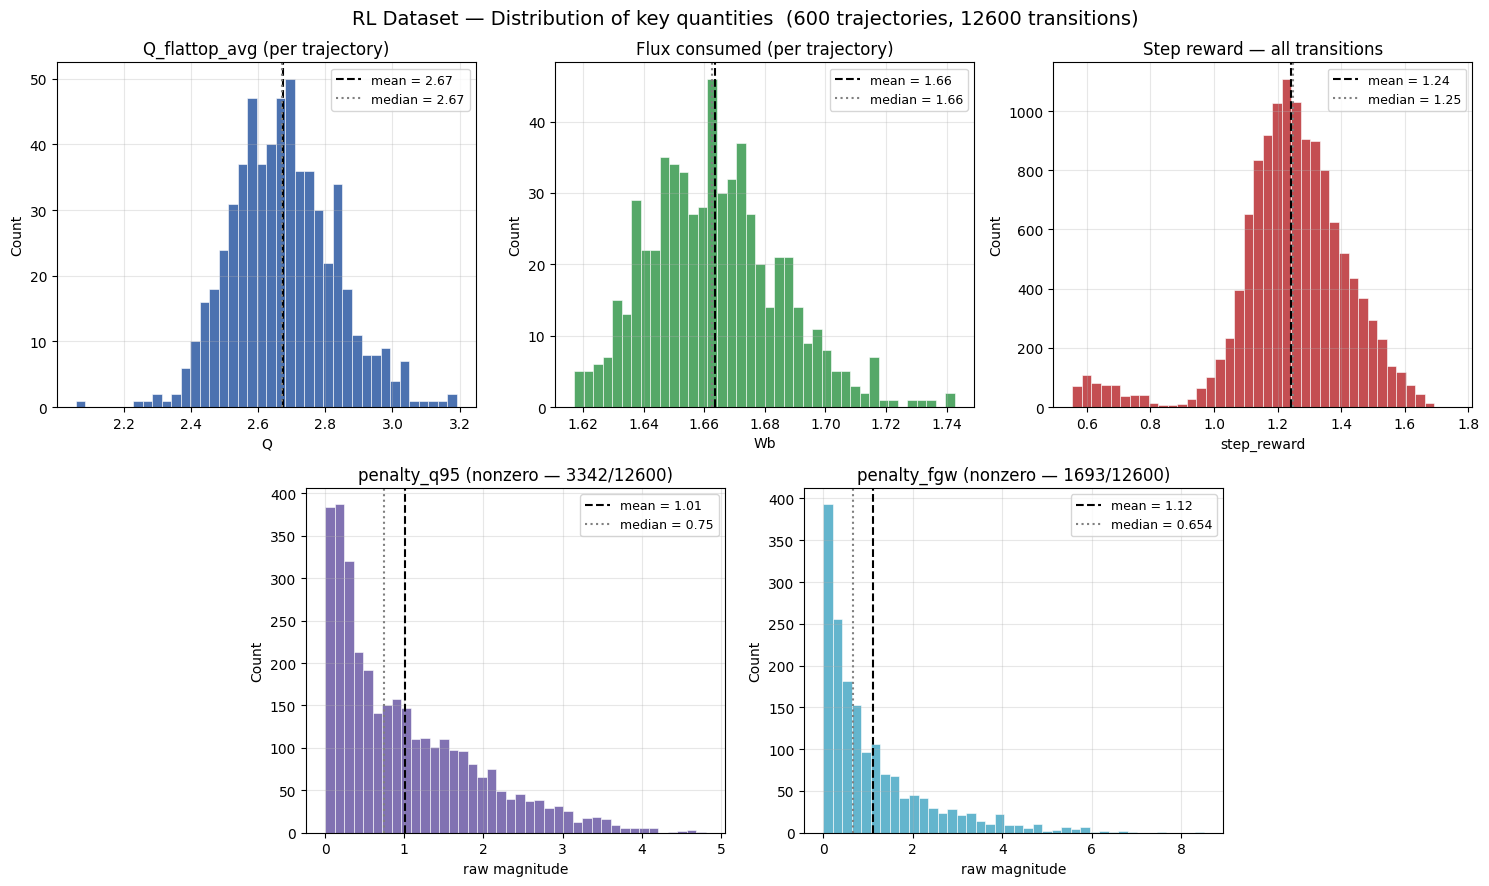

Figure saved → rl_dataset_preprocessed/reward_diagnostics.png


In [19]:
from matplotlib.gridspec import GridSpec

N_total = len(hist["new_reward"])

# Convert to numpy arrays for the helper
Q_flattop    = np.array(hist["weighted_Q_flattop"])
flux_wb      = np.array(hist["weighted_flux_consumed"])
step_rewards = np.array(hist["weighted_step_reward"])
penalty_q95  = np.array(hist["weighted_q95_penalty"])
penalty_fgw  = np.array(hist["weighted_fgw_penalty"])

n_q95 = int(np.sum(penalty_q95 > 0))
n_fgw = int(np.sum(penalty_fgw > 0))

def hist_plot(ax, data, title, xlabel, color, nonzero_only=False):
    d = data[~np.isnan(data)]
    if nonzero_only:
        d = d[d > 0]
    if len(d) == 0:
        ax.text(0.5, 0.5, 'No nonzero values', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title)
        return
    ax.hist(d, bins=40, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(np.mean(d), color='black', lw=1.5, linestyle='--',
               label=f'mean = {np.mean(d):.3g}')
    ax.axvline(np.median(d), color='gray', lw=1.5, linestyle=':',
               label=f'median = {np.median(d):.3g}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig = plt.figure(figsize=(15, 9))
gs = GridSpec(2, 6, figure=fig)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 1:3])  # offset by 1 to centre
ax5 = fig.add_subplot(gs[1, 3:5])  # offset by 1 to centre

hist_plot(ax1, Q_flattop,    'Q_flattop_avg (per trajectory)',              'Q',           '#4C72B0')
hist_plot(ax2, flux_wb,      'Flux consumed (per trajectory)',              'Wb',           '#55A868')
hist_plot(ax3, step_rewards, 'Step reward — all transitions',              'step_reward',  '#C44E52')
hist_plot(ax4, penalty_q95,  f'penalty_q95 (nonzero — {n_q95}/{N_total})', 'raw magnitude','#8172B2', nonzero_only=True)
hist_plot(ax5, penalty_fgw,  f'penalty_fgw (nonzero — {n_fgw}/{N_total})', 'raw magnitude','#64B5CD', nonzero_only=True)

plt.suptitle(
    f'RL Dataset — Distribution of key quantities  ({files_ok} trajectories, {N_total} transitions)',
    fontsize=14
)
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "reward_diagnostics.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {plot_path}")

## ── Quick sanity check ───────────────────────────────────────────────────────

In [ ]:
# Spot-check the first output file
first_out = os.path.join(OUTPUT_DIR, os.path.basename(input_files[0]))
with open(first_out) as f:
    sample = json.load(f)

print("=== First output file:", os.path.basename(first_out), "===")
print("State keys:")
print(list(sample["transitions"][0]["s"].keys()))

print("\n--- Confirm removed fields are absent ---")
s0 = sample["transitions"][0]["s"]
for field in REMOVE_FROM_STATE + REMOVE_REWARD_FIELDS:
    status = "PRESENT (unexpected!)" if field in s0 else "absent ✓"
    print(f"  {field}: {status}")

print("\n=== Reward statistics (all transitions, all files) ===")
rewards = hist["new_reward"]
print(f"  count = {len(rewards)}")
print(f"  min   = {min(rewards):.4f}")
print(f"  max   = {max(rewards):.4f}")
print(f"  mean  = {np.mean(rewards):.4f}")
print(f"  std   = {np.std(rewards):.4f}")

Loaded 600 trajectories, 12600 total transitions


/var/folders/rq/m1r647g16dl5vyfwm65mqqvr0000gn/T/ipykernel_73619/4176331986.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


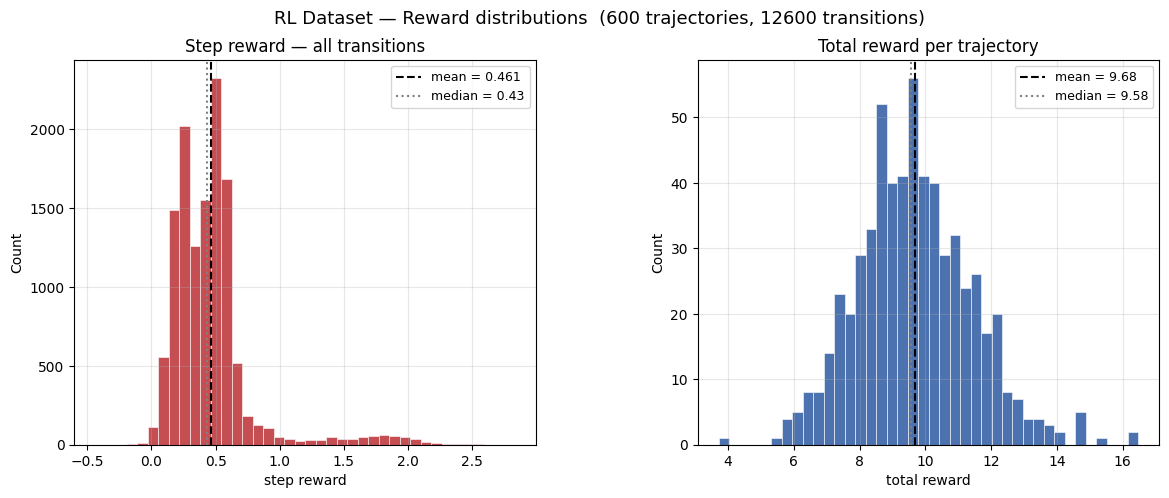

Saved → reward_histograms.png


In [8]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Config ──────────────────────────────────────────────────────────────────
DATASET_DIR = "test/"

# ── Load all JSON files ──────────────────────────────────────────────────────
step_rewards = []       # one entry per transition across all trajectories
total_rewards = []      # one entry per trajectory (sum of r over transitions)

files_ok = 0
for fname in sorted(os.listdir(DATASET_DIR)):
    if not fname.endswith(".json"):
        continue
    fpath = os.path.join(DATASET_DIR, fname)
    try:
        with open(fpath) as f:
            data = json.load(f)
        transitions = data["transitions"]
        rs = [t["r"] for t in transitions]
        step_rewards.extend(rs)
        total_rewards.append(sum(rs))
        files_ok += 1
    except Exception as e:
        print(f"Skipping {fname}: {e}")

step_rewards = np.array(step_rewards)
total_rewards = np.array(total_rewards)

print(f"Loaded {files_ok} trajectories, {len(step_rewards)} total transitions")

# ── Plot helper ──────────────────────────────────────────────────────────────
def hist_plot(ax, data, title, xlabel, color):
    d = data[~np.isnan(data)]
    if len(d) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title)
        return
    ax.hist(d, bins=40, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(np.mean(d), color='black', lw=1.5, linestyle='--',
               label=f'mean = {np.mean(d):.3g}')
    ax.axvline(np.median(d), color='gray', lw=1.5, linestyle=':',
               label=f'median = {np.median(d):.3g}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

hist_plot(ax1, step_rewards,  'Step reward — all transitions',       'step reward',      '#C44E52')
hist_plot(ax2, total_rewards, 'Total reward per trajectory',         'total reward',     '#4C72B0')

plt.suptitle(
    f'RL Dataset — Reward distributions  ({files_ok} trajectories, {len(step_rewards)} transitions)',
    fontsize=13
)
plt.tight_layout()
plt.savefig("reward_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reward_histograms.png")